# Compare Archive Metrics

Compare structural fingerprints of Ramsey colorings that scalar score alone cannot distinguish. Computed snapshots are stored in the `coloring_metrics` table beside the existing archive records.


In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ramsey import (
    METRIC_VERSION,
    RGraph,
    RMetricStore,
    RProblem,
    RSQLiteArchive,
    RSearchState,
    calculate_metrics,
)

N_VERTICES = 43
RANDOM_SEED = 202_608_070
EXACT_SCORE = 207
EXACT_SCORE_SAMPLE_SIZE = 10
SAMPLES_PER_BAND = 10
RECOMPUTE_STORED_METRICS = False

SCORE_BANDS = (
    (0, 149),
    (150, 199),
    (200, 249),
    (250, 299),
    (300, 399),
    (400, 599),
)

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

DATABASE_PATH = (
    project_root
    / 'data'
    / 'ramsey_colorings.sqlite3'
)

rng = np.random.default_rng(RANDOM_SEED)


In [2]:
graph_start = perf_counter()
graph = RGraph(RProblem.r55(n_vertices=N_VERTICES))
graph_elapsed = perf_counter() - graph_start

archive = RSQLiteArchive(DATABASE_PATH)
metric_store = RMetricStore(DATABASE_PATH)

print('Database:', DATABASE_PATH.resolve())
print('Archive colorings:', archive.coloring_count(graph))
print('Archive best:', archive.best_score(graph))
print('Stored metric snapshots:', metric_store.count())
print('Metric version:', METRIC_VERSION)
print('Graph setup:', f'{graph_elapsed:.3f}s')


Database: C:\code\RamseyNumber\data\ramsey_colorings.sqlite3
Archive colorings: 3261
Archive best: 129
Stored metric snapshots: 0
Metric version: 1
Graph setup: 1.502s


In [3]:
# Select an exact-score cohort plus random samples from broad score bands.
# Only archive metadata is loaded here; coloring bytes are loaded later.

selected_records = {}
record_groups = {}

def add_sample(records, group_name, sample_size):
    if not records:
        print(f'{group_name}: no archive records')
        return

    if len(records) > sample_size:
        indexes = rng.choice(
            len(records),
            size=sample_size,
            replace=False,
        )
        records = [records[int(index)] for index in indexes]

    for record in records:
        selected_records[record.coloring_id] = record
        record_groups.setdefault(record.coloring_id, set()).add(group_name)

    print(f'{group_name}: selected {len(records)}')

exact_records = archive.colorings_in_score_range(
    minimum_score=EXACT_SCORE,
    maximum_score=EXACT_SCORE,
    graph=graph,
)
add_sample(exact_records, f'exact-{EXACT_SCORE}', EXACT_SCORE_SAMPLE_SIZE)

for minimum_score, maximum_score in SCORE_BANDS:
    candidates = archive.colorings_in_score_range(
        minimum_score=minimum_score,
        maximum_score=maximum_score,
        graph=graph,
    )
    add_sample(
        candidates,
        f'{minimum_score}-{maximum_score}',
        SAMPLES_PER_BAND,
    )

print('Unique colorings selected:', len(selected_records))


exact-207: no archive records
0-149: selected 10
150-199: selected 10
200-249: no archive records
250-299: selected 10
300-399: selected 10
400-599: selected 10
Unique colorings selected: 50


In [4]:
# Calculate missing fingerprints, persist them, and build a comparison table.

snapshots = {}
rows = []
analysis_start = perf_counter()

for index, record in enumerate(selected_records.values(), start=1):
    use_stored = (
        not RECOMPUTE_STORED_METRICS
        and metric_store.contains(record.coloring_id)
    )

    if use_stored:
        snapshot = metric_store.load(record.coloring_id).snapshot
        source = 'stored'
    else:
        archived = archive.load_coloring(record.coloring_id, graph)
        state = RSearchState(archived.coloring)
        snapshot = calculate_metrics(state)

        if snapshot.score != record.score:
            raise RuntimeError(
                f'Metric score {snapshot.score} disagrees with '
                f'archive score {record.score} for ID {record.coloring_id}.'
            )

        metric_store.save(record.coloring_id, snapshot)
        source = 'computed'

    snapshots[record.coloring_id] = snapshot

    row = {
        'coloring_id': record.coloring_id,
        'groups': ', '.join(sorted(record_groups[record.coloring_id])),
        'metric_source': source,
        **snapshot.summary(),
    }
    rows.append(row)

    print(
        f'{index:3d}/{len(selected_records):3d} | '
        f'id={record.coloring_id:5d} | '
        f'score={record.score:4d} | '
        f'{source}'
    )

analysis_elapsed = perf_counter() - analysis_start
metrics_frame = pd.DataFrame(rows).sort_values(
    ['score', 'coloring_id']
).reset_index(drop=True)

print()
print('Analyzed:', len(metrics_frame))
print('Stored metric snapshots:', metric_store.count())
print('Elapsed:', f'{analysis_elapsed:.3f}s')


  1/ 50 | id= 3081 | score= 145 | computed
  2/ 50 | id= 2837 | score= 147 | computed
  3/ 50 | id= 3019 | score= 147 | computed
  4/ 50 | id= 3254 | score= 143 | computed
  5/ 50 | id= 3146 | score= 141 | computed
  6/ 50 | id= 3203 | score= 141 | computed
  7/ 50 | id= 3045 | score= 149 | computed
  8/ 50 | id= 2963 | score= 140 | computed
  9/ 50 | id= 2833 | score= 146 | computed
 10/ 50 | id= 2997 | score= 148 | computed
 11/ 50 | id= 2723 | score= 156 | computed
 12/ 50 | id= 2382 | score= 172 | computed
 13/ 50 | id= 2451 | score= 156 | computed
 14/ 50 | id= 2240 | score= 168 | computed
 15/ 50 | id= 2791 | score= 153 | computed
 16/ 50 | id= 2619 | score= 153 | computed
 17/ 50 | id= 2374 | score= 162 | computed
 18/ 50 | id= 2324 | score= 170 | computed
 19/ 50 | id= 2407 | score= 150 | computed
 20/ 50 | id= 2855 | score= 151 | computed
 21/ 50 | id= 1761 | score= 293 | computed
 22/ 50 | id= 1866 | score= 294 | computed
 23/ 50 | id= 1321 | score= 292 | computed
 24/ 50 | i

In [5]:
# This is the key experiment: equal Ramsey score, different structure.

comparison_columns = [
    'coloring_id',
    'score',
    'red_violations',
    'blue_violations',
    'red_deficit_1',
    'blue_deficit_1',
    'max_vertex_violation_load',
    'max_edge_violation_load',
    'shared_edge_violation_pairs',
    'best_single_flip_reward',
    'improving_single_flips',
    'neutral_single_flips',
    'mean_single_flip_reward',
    'std_single_flip_reward',
]

same_score = metrics_frame[metrics_frame['score'] == EXACT_SCORE]

if same_score.empty:
    print(f'No score-{EXACT_SCORE} colorings were selected.')
else:
    display(same_score[comparison_columns])


No score-207 colorings were selected.


,coloring_id,score,red_violations,blue_violations,red_deficit_1,blue_deficit_1,max_vertex_violation_load,max_edge_violation_load,shared_edge_violation_pairs,best_single_flip_reward,improving_single_flips,neutral_single_flips,mean_single_flip_reward,std_single_flip_reward
0,2963,140,77,63,6030,5879,28,8,624,0,0,2,-11.637874,6.079447
1,3146,141,80,61,5654,6034,26,8,647,0,0,2,-11.382060,5.590808
2,3203,141,67,74,6141,5646,26,7,649,0,0,5,-11.491694,5.778266
3,3254,143,74,69,5919,5890,28,7,652,0,0,3,-11.493909,5.780377
4,3081,145,71,74,5881,6081,26,9,720,0,0,5,-11.641196,6.033475
5,2833,146,81,65,5935,5911,25,9,702,0,0,3,-11.501661,5.752148
6,2837,147,75,72,5916,5911,28,7,710,0,0,2,-11.469546,5.779916
7,3019,147,69,78,5777,5910,26,10,712,0,0,5,-11.314507,5.661813
8,2997,148,64,84,6231,5623,30,9,793,-1,0,0,-11.488372,5.687081
9,3045,149,76,73,6109,5572,27,8,738,0,0,4,-11.285714,5.672327


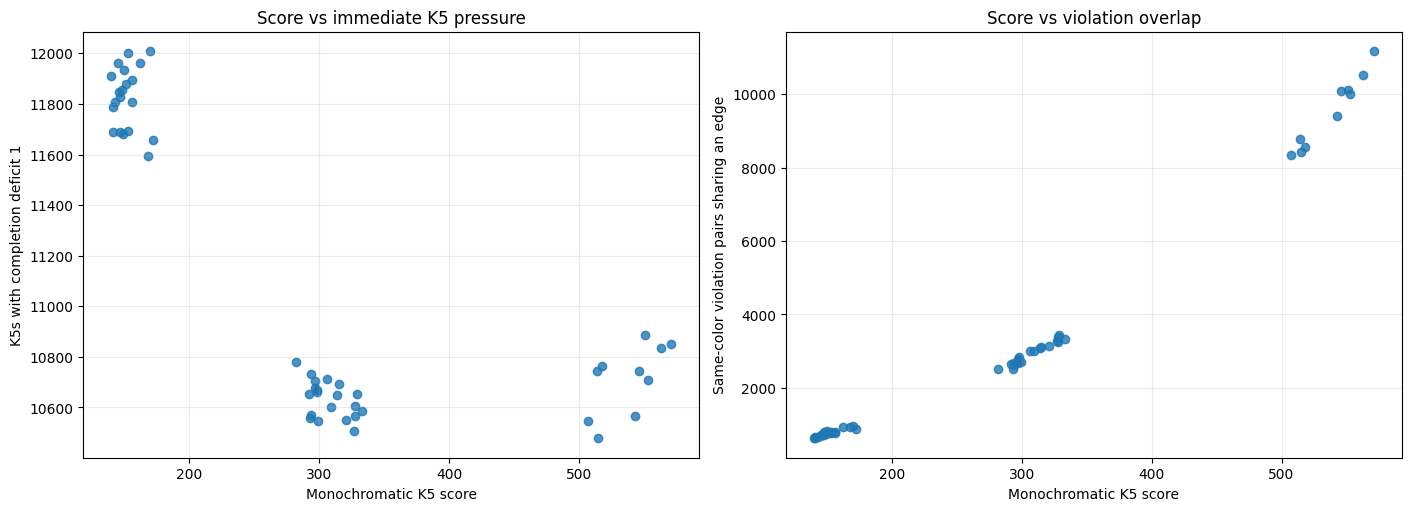

In [6]:
# Compare the selected archive tiers. No additional computation occurs here.

display(metrics_frame[comparison_columns])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].scatter(
    metrics_frame['score'],
    metrics_frame['red_deficit_1'] + metrics_frame['blue_deficit_1'],
    alpha=0.8,
)
axes[0].set_xlabel('Monochromatic K5 score')
axes[0].set_ylabel('K5s with completion deficit 1')
axes[0].set_title('Score vs immediate K5 pressure')
axes[0].grid(alpha=0.25)

axes[1].scatter(
    metrics_frame['score'],
    metrics_frame['shared_edge_violation_pairs'],
    alpha=0.8,
)
axes[1].set_xlabel('Monochromatic K5 score')
axes[1].set_ylabel('Same-color violation pairs sharing an edge')
axes[1].set_title('Score vs violation overlap')
axes[1].grid(alpha=0.25)

plt.show()


In [7]:
# Plot the two directional completion-deficit profiles for equal-score states.

if not same_score.empty:
    selected_ids = same_score['coloring_id'].head(4).astype(int).tolist()
    fig, axes = plt.subplots(
        len(selected_ids),
        1,
        figsize=(11, 3.2 * len(selected_ids)),
        sharex=True,
        constrained_layout=True,
    )

    if len(selected_ids) == 1:
        axes = [axes]

    for ax, coloring_id in zip(axes, selected_ids):
        snapshot = snapshots[coloring_id]
        deficits = np.arange(len(snapshot.red_deficit_histogram))

        ax.plot(
            deficits,
            snapshot.red_deficit_histogram,
            marker='o',
            color='firebrick',
            label='red completion deficit',
        )
        ax.plot(
            deficits,
            snapshot.blue_deficit_histogram,
            marker='o',
            color='royalblue',
            label='blue completion deficit',
        )
        ax.set_yscale('log')
        ax.set_ylabel('K5 count')
        ax.set_title(f'Archive {coloring_id} | score {snapshot.score}')
        ax.grid(alpha=0.25)
        ax.legend()

    axes[-1].set_xlabel('Edges that must change to complete the named color')
    plt.show()


In [8]:
metric_store.close()
archive.close()
print('Archive and metric store closed.')


Archive and metric store closed.
